# Beyond Churn: Causal Uplift Modeling

This notebook explores a simple question:

> **Are the customers most likely to churn also the customers that are most likely to benefit from a targeted retention treatment?**

I will compare a predictive churn-risk model with three causal treatment-effect approaches:

- T-Learner
- DRLearner
- CausalForestDML

My goal here is not to find the most complicated model. The goal is to compare targeting decisions on a held-out randomized experiment.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import openml

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, XGBRegressor
from econml.dr import DRLearner
from econml.dml import CausalForestDML

RANDOM_STATE = 42

## 1. Load and prepare the data

The dataset contains customer features, a randomized treatment indicator (`t`), and our churn outcome (`y`).

`y = 1` means the customer churned. And note that a positive **retention uplift** means treatment reduced churn.

In [2]:
dataset = openml.datasets.get_dataset(45580)

X_raw, y, _, _ = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

df = X_raw.copy()
df["y"] = y

treatment = df["t"].astype(int)
y = df["y"].astype(int)

X = df.drop(columns=["t", "y"]).copy()

# FACTOR3 is constant and provides no modeling information.
if "FACTOR3" in X.columns:
    X = X.drop(columns=["FACTOR3"])

categorical_cols = X.select_dtypes(
    include=["object", "string", "str", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_cols] = X[categorical_cols].astype(str)

print("Rows:", len(X))
print("Features:", X.shape[1])
print("Treatment rate:", treatment.mean().round(4))
print("Churn rate:", y.mean().round(4))

Rows: 11896
Features: 177
Treatment rate: 0.7574
Churn rate: 0.0343


## 2. Check the average treatment effect

Note that because the treatment was randomized the overall difference in churn between treatment and control should give us a simple experimental baseline.

In [3]:
control_churn = y[treatment == 0].mean()
treatment_churn = y[treatment == 1].mean()
overall_retention_uplift = control_churn - treatment_churn

print(f"Control churn rate:   {control_churn:.4f}")
print(f"Treatment churn rate: {treatment_churn:.4f}")
print(f"Retention uplift:     {overall_retention_uplift:.4f}")

Control churn rate:   0.0364
Treatment churn rate: 0.0336
Retention uplift:     0.0028


The average treatment effect is small. That does not mean treatment is equally useful for every customer. The rest of the notebook looks for differences in treatment response.

## 3. Create a hold-out causal evaluation set

All models will use the same training and evaluation split so the targeting comparison is fair

In [4]:
causal_strata = treatment.astype(str) + "_" + y.astype(str)

train_idx, eval_idx = train_test_split(
    X.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=causal_strata
)

X_causal_train = X.loc[train_idx].copy()
X_causal_eval = X.loc[eval_idx].copy()

y_causal_train = y.loc[train_idx].copy()
y_causal_eval = y.loc[eval_idx].copy()

treatment_train = treatment.loc[train_idx].copy()
treatment_eval = treatment.loc[eval_idx].copy()

eval_results = pd.DataFrame({
    "y": y_causal_eval,
    "treatment": treatment_eval
})

print("Training rows:", len(X_causal_train))
print("Evaluation rows:", len(X_causal_eval))

Training rows: 8922
Evaluation rows: 2974


## 4. Predictive baseline: churn risk

The predictive model answers:

> **Who is most likely to churn without intervention?**

The predictive churn model will be based on the winning model from notebook 02, which was LightGBM. And I will reuse the same LightGBM settings selected from RandomizedSearchCV. But note that I will refit the model only on control customers from this training split. This should keep the held-out policy comparison fair.

In [5]:
# first I'll use the same preprocessing approach as Notebook 02
risk_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

# Then use the best LightGBM parameters found in Notebook 02
risk_model = Pipeline([
    ("preprocess", risk_preprocessor),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            n_estimators=300,
            num_leaves=15,
            max_depth=-1,
            learning_rate=0.03,
            subsample=1.0,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

# Train churn risk on untreated users
X_risk_train = X_causal_train.loc[
    treatment_train == 0
].copy()

y_risk_train = y_causal_train.loc[
    treatment_train == 0
].copy()

risk_model.fit(
    X_risk_train,
    y_risk_train
)

# score every customer in the causal evaluation set
eval_results["predicted_churn_risk"] = (
    risk_model.predict_proba(X_causal_eval)[:, 1]
)

In [6]:
# Distribution of predicted churn risk scores
pd.Series(
    eval_results["predicted_churn_risk"],
    name="Predicted churn risk score"
).describe()

count    2974.000000
mean        0.003619
std         0.014568
min         0.000011
25%         0.000139
50%         0.000362
75%         0.001376
max         0.272950
Name: Predicted churn risk score, dtype: float64

In [7]:
# evaluate churn risk ranking on untreated evaluation customers
control_eval_mask = treatment_eval == 0

control_eval_predictions = eval_results.loc[
    control_eval_mask,
    "predicted_churn_risk"
]

control_eval_y = y_causal_eval.loc[
    control_eval_mask
]

print(
    "ROC AUC:",
    roc_auc_score(
        control_eval_y,
        control_eval_predictions
    )
)

print(
    "Average precision:",
    average_precision_score(
        control_eval_y,
        control_eval_predictions
    )
)

ROC AUC: 0.8313779745434422
Average precision: 0.17296517776034911


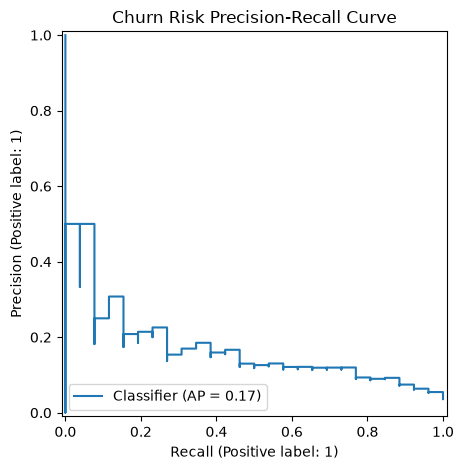

In [8]:
# precision-recall curve
# good for rare outcomes
PrecisionRecallDisplay.from_predictions(
    control_eval_y,
    control_eval_predictions
)

plt.title("Churn Risk Precision-Recall Curve")
plt.tight_layout()
plt.show()

**Summary:** The LightGBM model retains good ranking performance on the sample, with ROC AUC of 0.831 and Average Precision of 0.173. Predicted risk is concentrated around low values with a smaller high-risk tail. So note that the scores are used primarily for ranking customers rather than as calibrated probabilities.

## 5. T-Learner baseline

A T-Learner fits separate outcome models for treatment and control. And the difference between their predicted churn probabilities becomes the estimated retention uplift.

In [9]:
# Preprocess numeric and categorical features for the causal models
causal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

# T-learner -- this will fit one outcome model for control customers
control_model = Pipeline([
    ("preprocess", clone(causal_preprocessor)),
    (
        "model",
        CalibratedClassifierCV(
            LogisticRegression(max_iter=2000),
            method="sigmoid",
            cv=5
        )
    )
])

# Fit a separate outcome model for treated
treatment_model = Pipeline([
    ("preprocess", clone(causal_preprocessor)),
    (
        "model",
        CalibratedClassifierCV(
            LogisticRegression(max_iter=2000),
            method="sigmoid",
            cv=5
        )
    )
])

control_model.fit(
    X_causal_train.loc[treatment_train == 0],
    y_causal_train.loc[treatment_train == 0]
)

treatment_model.fit(
    X_causal_train.loc[treatment_train == 1],
    y_causal_train.loc[treatment_train == 1]
)

# Predict each customer's outcome under control and treatment
pred_control = control_model.predict_proba(X_causal_eval)[:, 1]
pred_treatment = treatment_model.predict_proba(X_causal_eval)[:, 1]

# Note: positive values mean treatment is predicted to reduce churn
eval_results["predicted_t_uplift"] = pred_control - pred_treatment

In [10]:
pd.Series(
    eval_results["predicted_t_uplift"],
    name="T-Learner retention uplift"
).describe()

count    2974.000000
mean        0.004727
std         0.037722
min        -0.556440
25%        -0.005122
50%         0.006864
75%         0.018028
max         0.531541
Name: T-Learner retention uplift, dtype: float64

**Summary:** The T-Learner predicts a small positive average retention uplift of about 0.5 percentage points. Most have estimated effects close to zero. But there is meaningful variation across customers, including both negative and strongly positive predicted treatment effects.

The median predicted uplift is ~0.7 percentage points, and the middle 50% of customers fall between roughly -0.5 and +1.8 percentage points.

## 6. Prepare numeric features for EconML

The following causal models need numeric inputs. I'm going to fit a preprocessing step on the training data and reuse it for evaluation.

In [11]:
# Important: EconML expects a fully numeric feature matrix
causal_numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

# Now fit preprocessing on the causal training set
X_causal_train_numeric = causal_numeric_preprocessor.fit_transform(
    X_causal_train
)

# apply the same transformation to the evaluation set
X_causal_eval_numeric = causal_numeric_preprocessor.transform(
    X_causal_eval
)

print("Training matrix:", X_causal_train_numeric.shape)
print("Evaluation matrix:", X_causal_eval_numeric.shape)

Training matrix: (8922, 335)
Evaluation matrix: (2974, 335)


## 7. DRLearner

DRLearner combines outcome modeling with treatment propensity to estimate customer-level treatment effects.

Note that because treatment was randomized, the propensity model only needs the overall treatment rate. XGBoost will be used for the outcome and final treatment-effect models.

In [12]:
# DRLearner combines the following
# 1: a treatment model
# 2: an outcome model
# 3: and a final model for treatment-effect heterogeneity

# first instantiate dr_learner
dr_learner = DRLearner(
    # because treatment was randomized I'm going to use a simple prior-based propensity model -- that should be enough
    model_propensity=DummyClassifier(strategy="prior"),

    # predict churn outcomes using boosted trees
    model_regression=XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    # model how treatment effects vary across customers
    model_final=XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE
)

# fit the doubly robust learner on the causal training sample
dr_learner.fit(
    np.asarray(y_causal_train).ravel(),
    np.asarray(treatment_train).ravel(),
    X=X_causal_train_numeric
)

# estimate the treatment effect for each evaluation customer
dr_effect = np.asarray(
    dr_learner.effect(
        X_causal_eval_numeric,
        T0=0,
        T1=1
    )
).ravel()

# EconML returns the effect on churn
# and we flip the sign so positive values mean predicted churn reduction / retention uplift
eval_results["predicted_dr_uplift"] = -dr_effect

pd.Series(
    eval_results["predicted_dr_uplift"],
    name="DRLearner retention uplift"
).describe()

count    2974.000000
mean        0.004089
std         0.059115
min        -0.383656
25%        -0.021580
50%        -0.003174
75%         0.017841
max         0.770833
Name: DRLearner retention uplift, dtype: float64

**Summary:** DRLearner predicts a small positive average retention uplift of ~0.4 percentage points. But we can see that the distribution is more spread out than the T-Learner.

The median effect is slightly negative, while the middle 50% of customers range from about -2.2 to +1.8 percentage points. This might suggest the model is identifying more variation in treatment response, including users who may be helped and others who may be harmed by the treatment.

## 8. CausalForestDML

CausalForestDML uses double machine learning and a causal forest to estimate treatment-effect heterogeneity

In [13]:
# I'll use CausalForestDML to estimate how treatment effects vary across customers
causal_forest = CausalForestDML(
    # outcome model for churn
    model_y=XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    # recall that treatment was randomized so a simple propensity model is enough
    model_t=DummyClassifier(strategy="prior"),

    discrete_outcome=True,
    discrete_treatment=True,

    # Forest settings for heterogeneous treatment-effect estimation
    n_estimators=500,
    min_samples_leaf=20,
    honest=True,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# now fit the causal forest on the numeric training matrix
causal_forest.fit(
    np.asarray(y_causal_train).ravel(),
    np.asarray(treatment_train).ravel(),
    X=X_causal_train_numeric
)

# Estimate the treatment effect for each evaluation customer
cf_effect = np.asarray(
    causal_forest.effect(
        X_causal_eval_numeric,
        T0=0,
        T1=1
    )
).ravel()

# Again we flip the sign so positive values mean retention uplift
eval_results["predicted_cf_uplift"] = -cf_effect

pd.Series(
    eval_results["predicted_cf_uplift"],
    name="CausalForestDML retention uplift"
).describe()

count    2974.000000
mean        0.001758
std         0.005089
min        -0.018491
25%        -0.001054
50%         0.001428
75%         0.004154
max         0.026787
Name: CausalForestDML retention uplift, dtype: float64

**Summary:** CausalForestDML predicts a much tighter distribution of treatment effects than both the T-Learner or DRLearner models.

The average predicted retention uplift is ~0.2 percentage points, with the middle 50% of customers ranging from roughly -0.1 to +0.4 percentage points. Most estimated effects are close to zero. This suggests the causal forest model is making more conservative treatment-effect estimates with less extreme variation across customers.

## 9. Compare targeting policies

Main decision question:

> **If we can only intervene on a limited share of customers, then which ranking should we use?**

Each model creates a different customer ranking. For each model, we target the highest-ranked customers and measure the observed treatment-control churn difference within that selected group.

Here, `control churn - treatment churn` is the observed retention uplift, and random targeting serves as the benchmark.

In [14]:
# we will compare several targeting budgets from top 5% to top 50% of customers
policy_budgets = [0.05, 0.10, 0.20, 0.30, 0.50]

# Each policy ranks customers using a different score
policy_columns = {
    "Churn risk": "predicted_churn_risk",
    "T-Learner": "predicted_t_uplift",
    "DRLearner": "predicted_dr_uplift",
    "CausalForestDML": "predicted_cf_uplift"
}

policy_rows = []

for fraction in policy_budgets:
    n_target = int(len(eval_results) * fraction)

    row = {
        "Targeting fraction": fraction,
        "Customers targeted": n_target
    }

    # for each policy we target the highest-ranked customers
    for policy_name, score_col in policy_columns.items():
        targeted = eval_results.nlargest(
            n_target,
            score_col
        )

        # measure observed churn separately in control and treatment
        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        # note that positive values mean treatment reduced churn in the targeted group
        row[policy_name] = (
            control_rate - treatment_rate
        )

    # and random targeting gives us a simple benchmark for comparison
    random_uplifts = []

    for seed in range(250):
        targeted = eval_results.sample(
            n=n_target,
            random_state=seed
        )

        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        random_uplifts.append(
            control_rate - treatment_rate
        )

    # Average across many random samples for a more stable benchmark
    row["Random"] = np.nanmean(
        random_uplifts
    )

    policy_rows.append(row)

policy_comparison = pd.DataFrame(
    policy_rows
)

policy_comparison

,Targeting fraction,Customers targeted,Churn risk,T-Learner,DRLearner,CausalForestDML,Random
0,0.05,148,0.091847,0.035352,0.041466,-0.038978,0.003507
1,0.10,297,0.027515,0.017917,-0.005045,-0.028984,0.003708
2,0.20,594,0.027972,0.007778,0.014223,-0.008547,0.003187
3,0.30,892,0.021286,0.005100,0.014459,-0.002809,0.003610
4,0.50,1487,0.025063,0.003682,0.007502,0.001610,0.003499


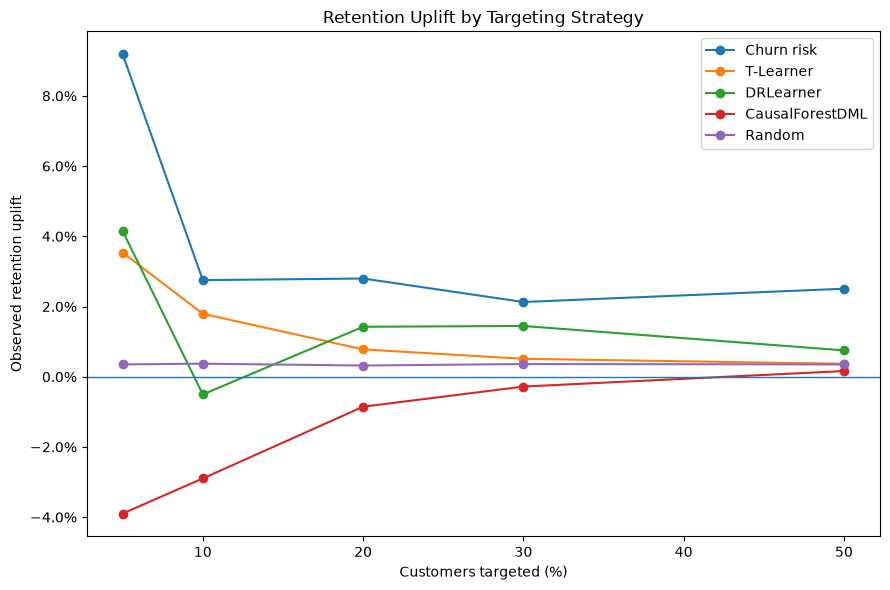

In [16]:
# plot
policy_plot = policy_comparison.copy()

# convert the targeting fraction to percentages for the x-axis
policy_plot["Customers targeted (%)"] = (
    policy_plot["Targeting fraction"] * 100
)

plt.figure(figsize=(9, 6))

# plot observed retention uplift for each targeting strategy
for policy in [
    "Churn risk",
    "T-Learner",
    "DRLearner",
    "CausalForestDML",
    "Random"
]:
    plt.plot(
        policy_plot["Customers targeted (%)"],
        policy_plot[policy],
        marker="o",
        label=policy
    )

# zero means no observed treatment effect
plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Customers targeted (%)")
plt.ylabel("Observed retention uplift")
plt.title("Retention Uplift by Targeting Strategy")

# show uplift as percentages rather than decimals
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.legend()
plt.tight_layout()
plt.show()

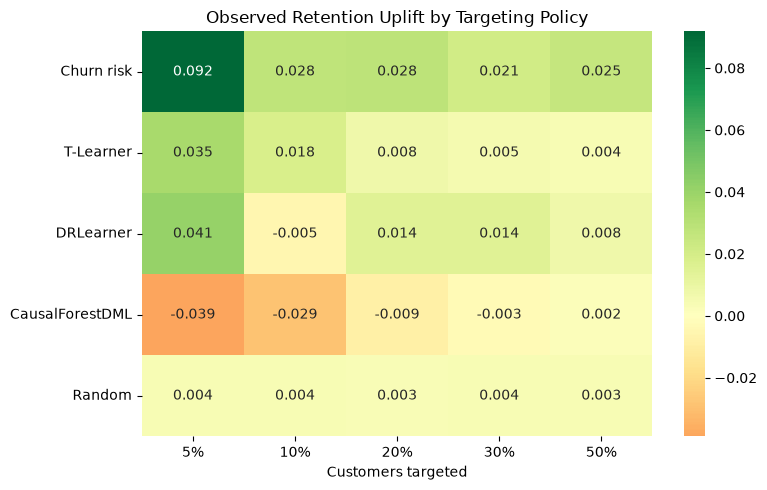

In [18]:
# heatmap of uplift by policy and targeting budget
# this helps us visually summarize where each policy performs well or poorly
policy_heatmap = (
    policy_comparison
    .set_index("Targeting fraction")[
        [
            "Churn risk",
            "T-Learner",
            "DRLearner",
            "CausalForestDML",
            "Random"
        ]
    ]
    .T
)

policy_heatmap.columns = [
    f"{int(fraction * 100)}%"
    for fraction in policy_heatmap.columns
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    policy_heatmap,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0
)

plt.xlabel("Customers targeted")
plt.ylabel("")
plt.title("Observed Retention Uplift by Targeting Policy")
plt.tight_layout()
plt.show()

## 10. Discussion

- Churn-risk targeting performed best at every targeting level, with the largest observed uplift in the top 5% of customers.
- DRLearner showed some strong results, especially at the 5%, 20%, and 30% targeting levels, but it was less stable overall.
- T-Learner produced consistently positive but smaller uplift across all targeting levels.
- CausalForestDML performed poorly in this particular sample, with negative observed uplift through the top 30% and only a small positive effect at 50%.
- Random targeting stayed close to zero and provided a useful baseline.
- Note that churn risk and treatment response are different modeling questions, but a causal model might not always produce the best targeting policy.
- The smallest targeting groups contain relatively few customers, and so the largest point estimates should be interpreted carefeully.

One key takeaway is that a good prediction model is not always the best decision model. And causal models also do not automatically produce better targeting. What matters is how well each approach performs for the actual decision we need to make.